In [2]:
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, MaxPool2D, Flatten, Dropout
from keras.utils import to_categorical
from keras.datasets import cifar10
import cv2
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Create  the object of image data generators

In [7]:
train_datagen = ImageDataGenerator(
    rescale = 1/255, 
    zoom_range = 0.2, 
    horizontal_flip = True, 
    vertical_flip = True
)

test_datagen = ImageDataGenerator(rescale = 1/255)

## Read the images

In [9]:
train = train_datagen.flow_from_directory(
    "D:\\AshleshaRuchika\\PGCP-AI\\NLP\\fruits\\training_set", 
    class_mode = "binary", 
    target_size = (64, 64)
)

Found 13 images belonging to 2 classes.


In [12]:
train.filenames

['apple\\1.jpg',
 'apple\\2.jpeg',
 'apple\\3.jpeg',
 'apple\\4.jpeg',
 'apple\\5.jpg',
 'apple\\6.jpg',
 'apple\\7.jpg',
 'orange\\1.jpeg',
 'orange\\2.jpg',
 'orange\\3.jpeg',
 'orange\\4.jpeg',
 'orange\\5.jpg',
 'orange\\6.jpg']

In [10]:
train.class_indices

{'apple': 0, 'orange': 1}

In [13]:
test = train_datagen.flow_from_directory(
    "D:\\AshleshaRuchika\\PGCP-AI\\NLP\\fruits\\test_set", 
    class_mode = "binary", 
    target_size = (64, 64)
)

Found 6 images belonging to 2 classes.


# Build the model

In [19]:
model = Sequential()

model.add(Input(shape = (64,64,3)))

model.add(Conv2D(16, (3,3), activation = 'relu'))
model.add(MaxPool2D(2,2))

model.add(Conv2D(8, (3,3), activation = 'relu'))
model.add(MaxPool2D(2,2))


model.add(Flatten())

model.add(Dense(32, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

In [20]:
model.compile(loss="binary_crossentropy",optimizer = "adam", metrics=["accuracy"])

In [21]:
model.fit(train,validation_data =test, epochs =10 , batch_size=1)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.2308 - loss: 0.7274 - val_accuracy: 0.5000 - val_loss: 0.6708
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.6154 - loss: 0.6621 - val_accuracy: 0.5000 - val_loss: 0.6526
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.6154 - loss: 0.6208 - val_accuracy: 0.6667 - val_loss: 0.6215
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.7692 - loss: 0.6023 - val_accuracy: 1.0000 - val_loss: 0.5911
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.8462 - loss: 0.5631 - val_accuracy: 1.0000 - val_loss: 0.5429
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 1.0000 - loss: 0.4933 - val_accuracy: 1.0000 - val_loss: 0.5112
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 1.0000 - loss: 0.4441 - val_accuracy: 1.0000 - val_loss: 0.4760
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 1.0000 - loss: 0.3961 - val_accuracy: 1.0000 - val_loss: 0.

## Prediction on new images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Orange


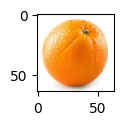

In [47]:

sample1= cv2.imread("D:\\AshleshaRuchika\\PGCP-AI\\NLP\\fruits\\sample1.jpg")
sample1 = cv2.cvtColor(sample1, cv2.COLOR_BGR2RGB)
sample1= cv2.resize(sample1, (64,64))
plt.figure(figsize=(1,1))
plt.imshow(sample1)
sample1 = sample1.reshape(1,64,64,3)
result = model.predict(sample1)
if result[0][0]==1:
  print('Orange')
else:
  print('Apple')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Apple


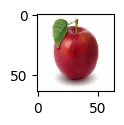

In [48]:


sample2= cv2.imread("D:\\AshleshaRuchika\\PGCP-AI\\NLP\\fruits\\sample2.jpg")
sample2 = cv2.cvtColor(sample2, cv2.COLOR_BGR2RGB)
sample2= cv2.resize(sample2, (64,64))
plt.figure(figsize=(1,1))
plt.imshow(sample2)
sample2 = sample2.reshape(1,64,64,3)
result = model.predict(sample2)
if result[0][0]==1:
  print('Orange')
else:
  print('Apple')
